<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-05-09 06:09:50--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  52.2MB/s    in 4.4s    

2026-05-09 06:09:55 (45.6 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 156.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 198.5 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 168.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 144.7 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


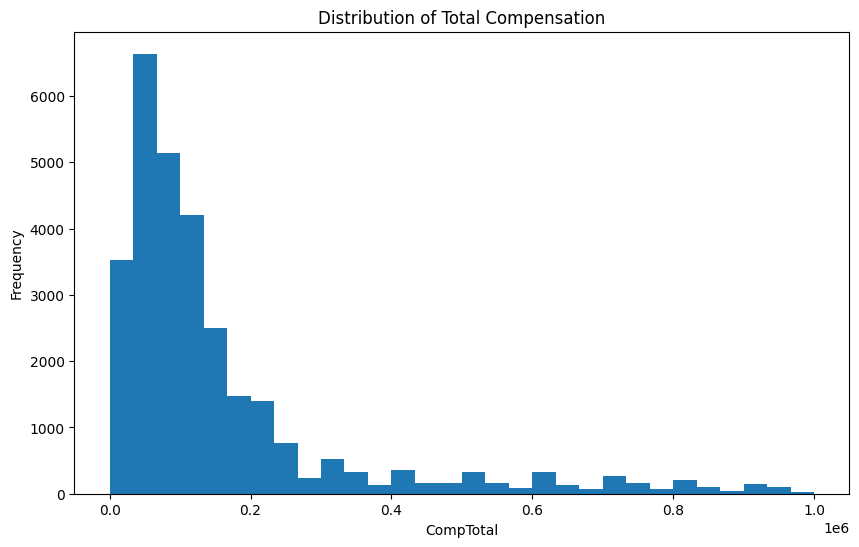

In [56]:
## Write your code here
# SQL query

QUERY = """
SELECT CompTotal
FROM main
"""


# Read SQL query

df_hist = pd.read_sql_query(QUERY, conn)


# Convert CompTotal into numeric

df_hist['CompTotal'] = pd.to_numeric(
    df_hist['CompTotal'],
    errors='coerce'
)

df_hist = df_hist[
    df_hist['CompTotal'] < 1000000]
# Remove missing values

df_hist = df_hist.dropna(subset=['CompTotal'])


# Create histogram

plt.figure(figsize=(10,6))

plt.hist(
    df_hist['CompTotal'],
    bins=30
)


# Add title and labels

plt.title("Distribution of Total Compensation")

plt.xlabel("CompTotal")

plt.ylabel("Frequency")


# Show graph

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


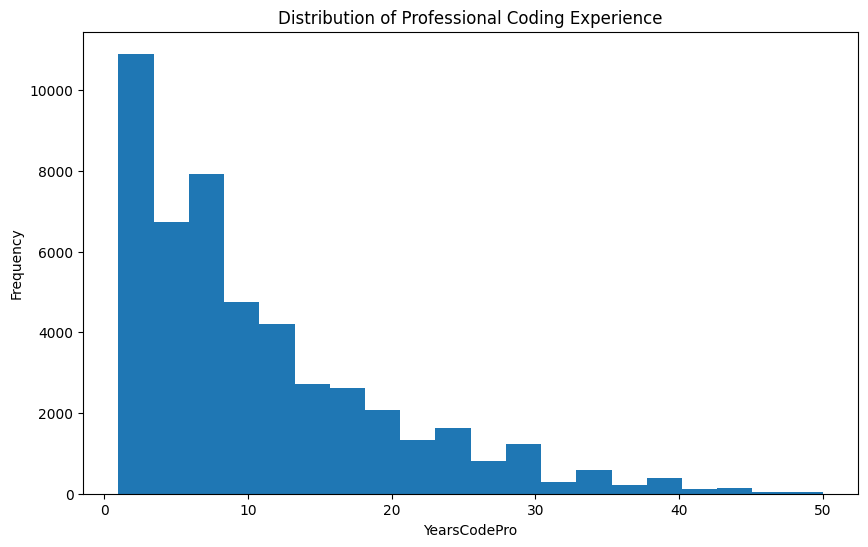

In [10]:
## Write your code here
# SQL query

QUERY = """
SELECT YearsCodePro
FROM main
"""


# Read query

df_years = pd.read_sql_query(QUERY, conn)


# Convert YearsCodePro into numeric

df_years['YearsCodePro'] = pd.to_numeric(
    df_years['YearsCodePro'],
    errors='coerce'
)


# Remove missing values

df_years = df_years.dropna(
    subset=['YearsCodePro']
)


# Create histogram

plt.figure(figsize=(10,6))

plt.hist(
    df_years['YearsCodePro'],
    bins=20
)


# Add title and labels

plt.title(
    "Distribution of Professional Coding Experience"
)

plt.xlabel("YearsCodePro")

plt.ylabel("Frequency")


# Show graph

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


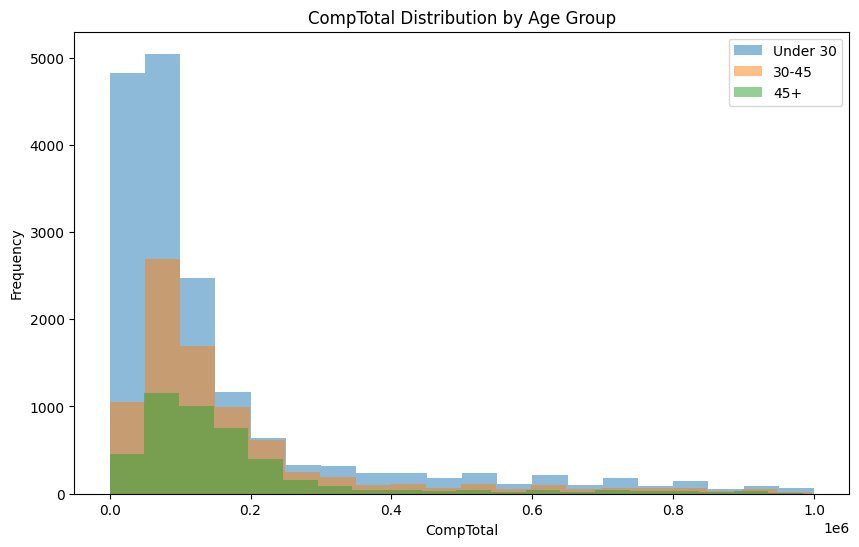

In [12]:
# SQL query

QUERY = """
SELECT Age, CompTotal
FROM main
"""


# Read query

df_age = pd.read_sql_query(QUERY, conn)


# Function to convert Age

def convert_age(age):

    if isinstance(age, str):

        age = age.lower().replace(
            "years old", ""
        ).strip()

        if "under" in age:
            return 17

        elif "-" in age:

            parts = age.split("-")

            return (
                int(parts[0]) + int(parts[1])
            ) / 2

    return None


# Convert Age

df_age['Age_convert'] = df_age['Age'].apply(
    convert_age
)


# Convert CompTotal

df_age['CompTotal'] = pd.to_numeric(
    df_age['CompTotal'],
    errors='coerce'
)


# Remove missing values

df_age = df_age.dropna(
    subset=['Age_convert', 'CompTotal']
)


# Remove extreme outliers

df_age = df_age[
    df_age['CompTotal'] < 1000000
]


# Create age groups

young = df_age[
    df_age['Age_convert'] < 30
]

middle = df_age[
    (df_age['Age_convert'] >= 30) &
    (df_age['Age_convert'] < 45)
]

older = df_age[
    df_age['Age_convert'] >= 45
]


# Create histogram

plt.figure(figsize=(10,6))

plt.hist(
    young['CompTotal'],
    bins=20,
    alpha=0.5,
    label='Under 30'
)

plt.hist(
    middle['CompTotal'],
    bins=20,
    alpha=0.5,
    label='30-45'
)

plt.hist(
    older['CompTotal'],
    bins=20,
    alpha=0.5,
    label='45+'
)


# Labels

plt.title(
    "CompTotal Distribution by Age Group"
)

plt.xlabel("CompTotal")

plt.ylabel("Frequency")

plt.legend()


# Show graph

plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


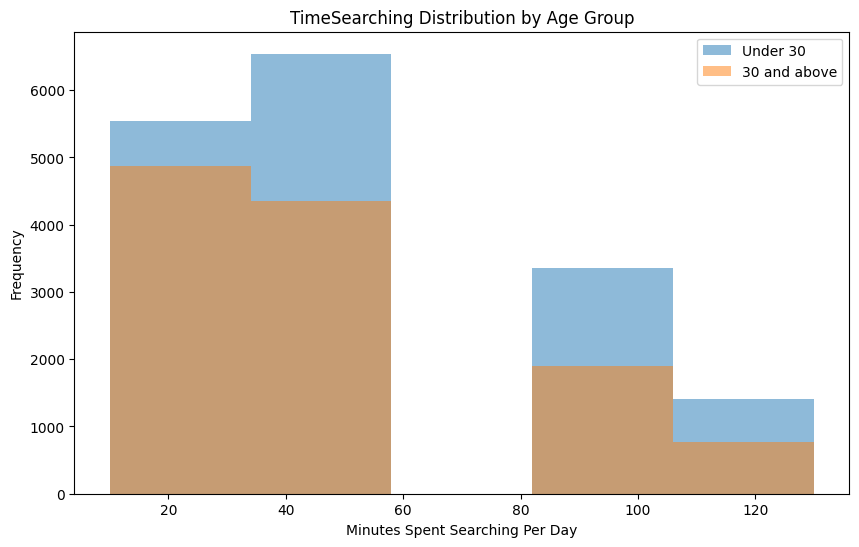

In [51]:
# SQL query

QUERY = """
SELECT Age, TimeSearching
FROM main
WHERE TimeSearching IS NOT NULL
"""


# Read query

df_search = pd.read_sql_query(QUERY, conn)


# Function to convert Age

def convert_age(age):

    if pd.isna(age):
        return None

    age = str(age).lower().replace(
        "years old", ""
    ).strip()


    # Handle Under 18

    if "under" in age:
        return 17


    # Handle ranges like 25-34

    elif "-" in age:

        parts = age.split("-")

        return (
            int(parts[0]) + int(parts[1])
        ) / 2


    # Handle single numeric ages

    elif age.isdigit():
        return int(age)


    return None


# Function to convert TimeSearching

def convert_time(time):

    if pd.isna(time):
        return None


    # Convert exact categories

    if time == 'Less than 15 minutes a day':
        return 10

    elif time == '15-30 minutes a day':
        return 22.5

    elif time == '30-60 minutes a day':
        return 45

    elif time == '60-120 minutes a day':
        return 90

    elif time == 'Over 120 minutes a day':
        return 130


    return None


# Convert Age column

df_search['Age_convert'] = df_search[
    'Age'
].apply(convert_age)


# Convert TimeSearching column

df_search['TimeSearching_convert'] = df_search[
    'TimeSearching'
].apply(convert_time)


# Remove missing values

df_search = df_search.dropna(
    subset=[
        'Age_convert',
        'TimeSearching_convert'
    ]
)


# Create age groups

young = df_search[
    df_search['Age_convert'] < 30
]

older = df_search[
    df_search['Age_convert'] >= 30
]


# Create histogram

plt.figure(figsize=(10,6))

plt.hist(
    young['TimeSearching_convert'],
    bins=5,
    alpha=0.5,
    label='Under 30'
)

plt.hist(
    older['TimeSearching_convert'],
    bins=5,
    alpha=0.5,
    label='30 and above'
)


# Add labels

plt.title(
    "TimeSearching Distribution by Age Group"
)

plt.xlabel(
    "Minutes Spent Searching Per Day"
)

plt.ylabel("Frequency")

plt.legend()


# Show graph

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


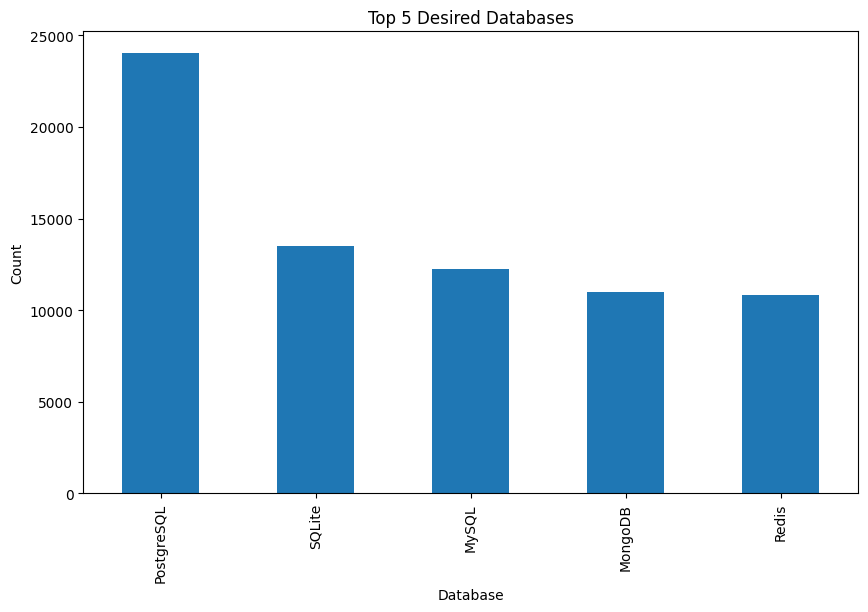

In [52]:
## Write your code here
# SQL query

QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""


# Read query

df_db = pd.read_sql_query(QUERY, conn)


# Split database names

db_split = df_db[
    'DatabaseWantToWorkWith'
].str.split(';')


# Convert lists into separate rows

db_exploded = db_split.explode()


# Count frequencies

top5 = db_exploded.value_counts().head(5)


# Create histogram/bar chart

plt.figure(figsize=(10,6))

top5.plot(kind='bar')


# Add labels

plt.title(
    "Top 5 Desired Databases"
)

plt.xlabel("Database")

plt.ylabel("Count")


# Show graph

plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


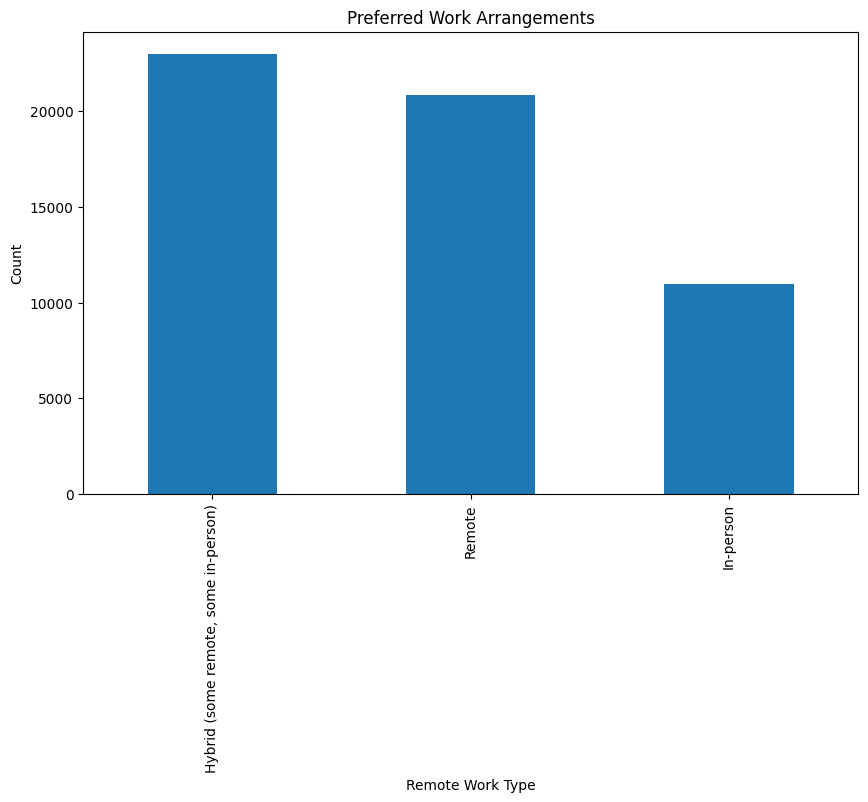

In [53]:
## Write your code here
# SQL query

QUERY = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL
"""


# Read query

df_remote = pd.read_sql_query(QUERY, conn)


# Count frequencies

remote_counts = df_remote[
    'RemoteWork'
].value_counts()


# Create bar chart

plt.figure(figsize=(10,6))

remote_counts.plot(kind='bar')


# Add labels

plt.title(
    "Preferred Work Arrangements"
)

plt.xlabel("Remote Work Type")

plt.ylabel("Count")


# Show graph

plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


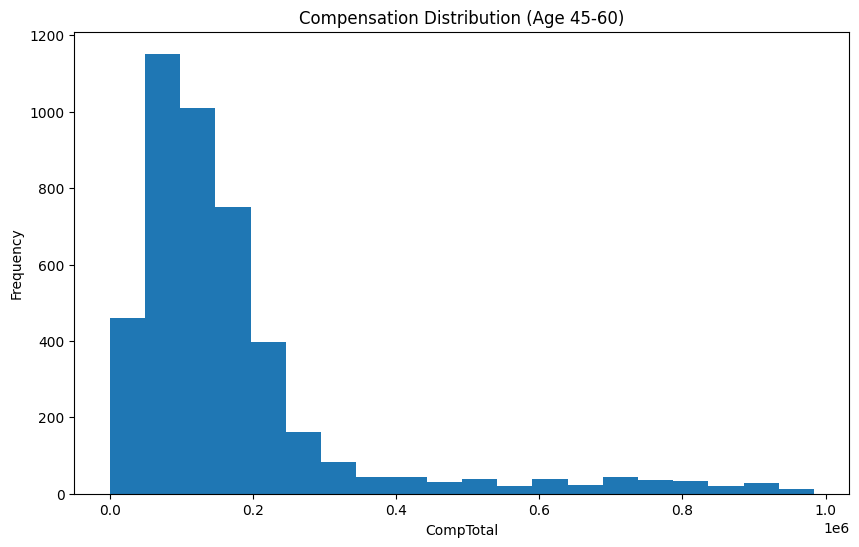

In [54]:
## Write your code here
# SQL query

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""


# Read query

df_comp = pd.read_sql_query(QUERY, conn)


# Convert Age

df_comp['Age_convert'] = df_comp[
    'Age'
].apply(convert_age)


# Convert CompTotal into numeric

df_comp['CompTotal'] = pd.to_numeric(
    df_comp['CompTotal'],
    errors='coerce'
)


# Remove missing values

df_comp = df_comp.dropna(
    subset=['Age_convert', 'CompTotal']
)


# Remove extreme outliers

df_comp = df_comp[
    df_comp['CompTotal'] < 1000000
]


# Keep only ages 45 to 60

filtered = df_comp[
    (df_comp['Age_convert'] >= 45) &
    (df_comp['Age_convert'] <= 60)
]


# Create histogram

plt.figure(figsize=(10,6))

plt.hist(
    filtered['CompTotal'],
    bins=20
)


# Add labels

plt.title(
    "Compensation Distribution (Age 45-60)"
)

plt.xlabel("CompTotal")

plt.ylabel("Frequency")


# Show graph

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


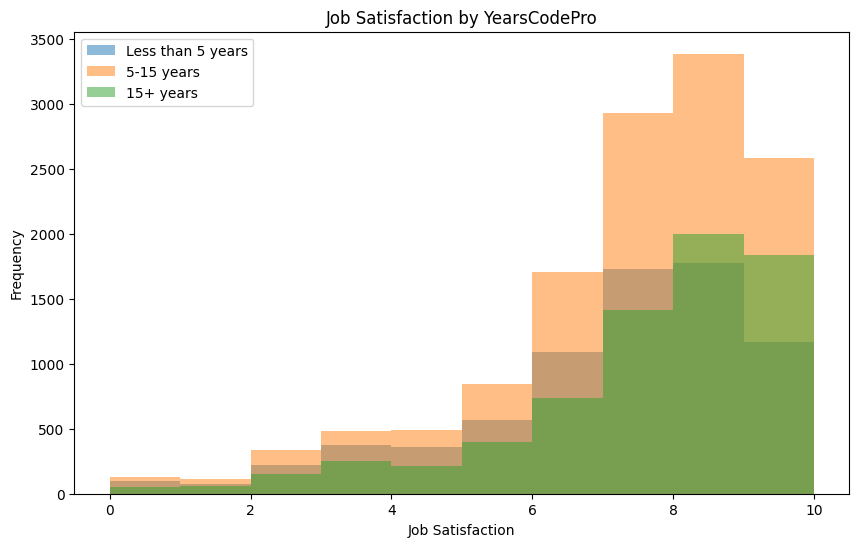

In [58]:
# SQL query

QUERY = """
SELECT JobSat, YearsCodePro
FROM main
WHERE JobSat IS NOT NULL
AND YearsCodePro IS NOT NULL
"""


# Read query

df_jobsat = pd.read_sql_query(QUERY, conn)


# Convert columns into numeric

df_jobsat['JobSat'] = pd.to_numeric(
    df_jobsat['JobSat'],
    errors='coerce'
)

df_jobsat['YearsCodePro'] = pd.to_numeric(
    df_jobsat['YearsCodePro'],
    errors='coerce'
)


# Remove missing values

df_jobsat = df_jobsat.dropna(
    subset=['JobSat', 'YearsCodePro']
)


# Create experience groups

beginner = df_jobsat[
    df_jobsat['YearsCodePro'] < 5
]

mid = df_jobsat[
    (df_jobsat['YearsCodePro'] >= 5) &
    (df_jobsat['YearsCodePro'] < 15)
]

experienced = df_jobsat[
    df_jobsat['YearsCodePro'] >= 15
]


# Create histogram

plt.figure(figsize=(10,6))

plt.hist(
    beginner['JobSat'],
    bins=10,
    alpha=0.5,
    label='Less than 5 years'
)

plt.hist(
    mid['JobSat'],
    bins=10,
    alpha=0.5,
    label='5-15 years'
)

plt.hist(
    experienced['JobSat'],
    bins=10,
    alpha=0.5,
    label='15+ years'
)


# Add labels

plt.title(
    "Job Satisfaction by YearsCodePro"
)

plt.xlabel("Job Satisfaction")

plt.ylabel("Frequency")

plt.legend()


# Show graph

plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [59]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
